In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Handling Missing numerical Data
    -->mean/median imputation
    -->Arbitary
    -->End of Distribution
    -->Randomely Selection

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [9]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [18]:
x_train['Age_median']=x_train['Age'].fillna(x_train['Age'].median())
x_train['Age_mean']=x_train['Age'].fillna(x_train['Age'].mean())

x_train['Fare_median']=x_train['Fare'].fillna(x_train['Fare'].median())
x_train['Fare_mean']=x_train['Fare'].fillna(x_train['Fare'].mean())

In [20]:
x_train.sample(10)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
733,23.0,13.0000,0,23.0,23.000000,13.0000,13.000000
841,16.0,10.5000,0,16.0,16.000000,10.5000,10.500000
816,23.0,NaN,0,23.0,23.000000,14.4000,32.517788
667,NaN,7.7750,0,28.0,29.498846,7.7750,7.775000
393,23.0,113.2750,1,23.0,23.000000,113.2750,113.275000
413,NaN,0.0000,0,28.0,29.498846,0.0000,0.000000
374,3.0,21.0750,4,3.0,3.000000,21.0750,21.075000
272,41.0,19.5000,1,41.0,41.000000,19.5000,19.500000
656,NaN,7.8958,0,28.0,29.498846,7.8958,7.895800
121,NaN,8.0500,0,28.0,29.498846,8.0500,8.050000


In [23]:
print("original age variable variance ",x_train['Age'].var())
print("age variable variance after median ",x_train['Age_median'].var())
print("age variance after mean imputation ",x_train["Age_mean"].var())

print("original Fare variable variance ",x_train['Fare'].var())
print("Fare variable variance after median ",x_train['Fare_median'].var())
print("Fare variance after mean imputation ",x_train["Fare_mean"].var())

original age variable variance  210.2517072477435
age variable variance after median  169.20731007048155
age variance after mean imputation  168.85193366872227
original Fare variable variance  2761.0314349486343
Fare variable variance after median  2637.012481677765
Fare variance after mean imputation  2621.232374951235


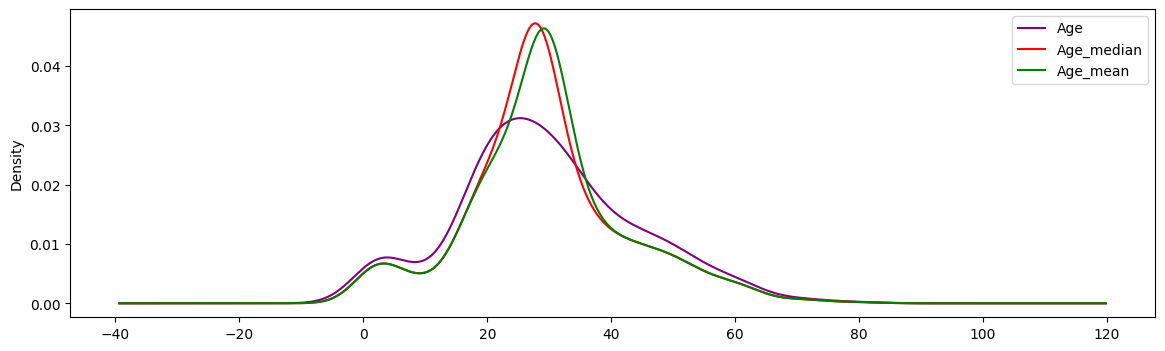

In [29]:
plt.figure(figsize=(14,4))
plt.subplot(111)
x_train['Age'].plot(kind='kde',color='purple')
x_train['Age_median'].plot(kind='kde',color='red')
x_train['Age_mean'].plot(kind='kde',color='green')
plt.legend()

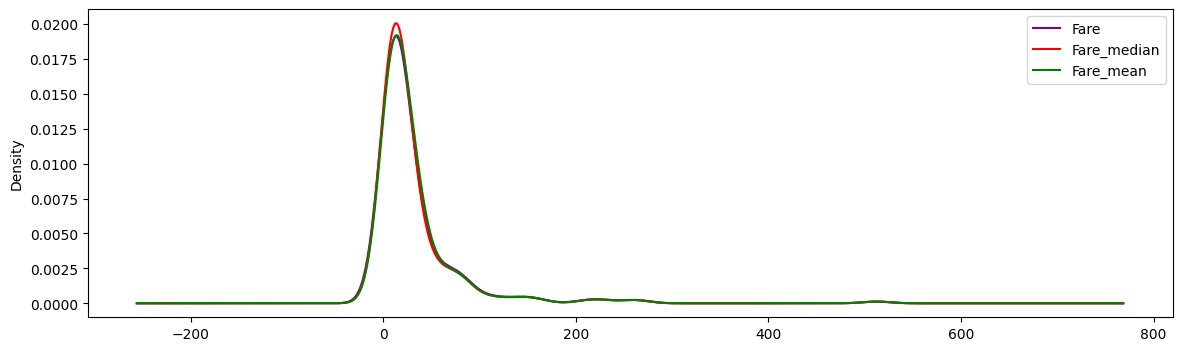

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(111)
x_train['Fare'].plot(kind='kde',color='purple')
x_train['Fare_median'].plot(kind='kde',color='red')
x_train['Fare_mean'].plot(kind='kde',color='green')
plt.legend()

In [32]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [33]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

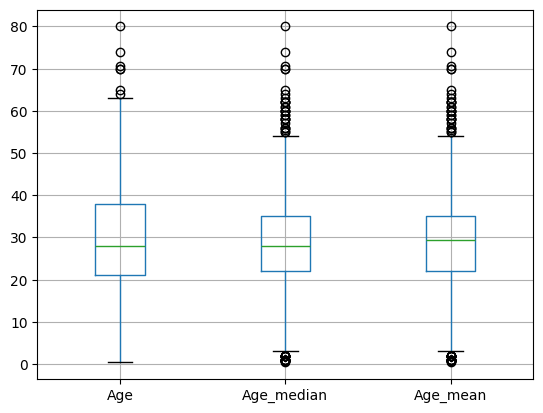

In [34]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

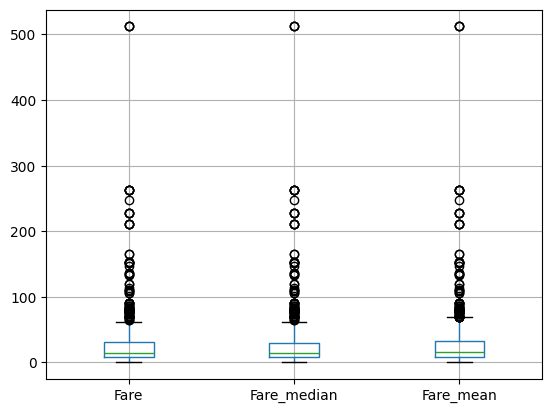

In [35]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

using sklearm

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [37]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [38]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [39]:
trf.fit(x_train)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [40]:
trf.named_transformers_

{'imputer1': SimpleImputer(strategy='median'),
 'imputer2': SimpleImputer(),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

3 Arbitary Value Imputation

4 End of Distribution Imputation